# Phase 3 — Step 2: Sentiment by Product Category

**Goal:** Join Mistral sentiment scores with product category data using DuckDB SQL to find which categories make customers happiest and which generate the most complaints.

**Stack:** DuckDB · Polars · Matplotlib

In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings
warnings.filterwarnings("ignore")

DB_PATH  = "../data/apex.duckdb"
CSV_OUT  = "../data/category_sentiment.csv"
FIGURES  = "../data/figures"
os.makedirs(FIGURES, exist_ok=True)
print("Setup complete.")


Setup complete.


In [2]:
# Load CSVs into Polars (only the columns we need)
items       = pl.read_csv("../data/olist_order_items_dataset.csv",
                  columns=["order_id", "product_id"])
products    = pl.read_csv("../data/olist_products_dataset.csv",
                  columns=["product_id", "product_category_name"])
translation = pl.read_csv("../data/product_category_name_translation.csv",
                  encoding="utf8-lossy")

# Register in DuckDB for the join
with duckdb.connect(DB_PATH) as conn:
    conn.register("items",       items)
    conn.register("products",    products)
    conn.register("translation", translation)

    # Four-way join: sentiment → order_items → products → translation
    df = conn.execute('''
        SELECT s.review_id,
               s.order_id,
               s.review_score                                     AS star_rating,
               s.sentiment,
               s.review_comment_message,
               COALESCE(t.product_category_name_english,
                        p.product_category_name, 'Unknown')       AS category
        FROM   sentiment    s
        LEFT   JOIN items       i USING (order_id)
        LEFT   JOIN products    p USING (product_id)
        LEFT   JOIN translation t
               ON  p.product_category_name = t.product_category_name
    ''').pl()

total        = len(df)
unknown_rows = df.filter(pl.col("category") == "Unknown")
no_product   = df.filter(pl.col("category").is_null())

print(f"Joined rows  : {total:,}")
print(f"Unknown cat  : {len(unknown_rows):,}  ({len(unknown_rows)/total:.1%})  — order_id not in items or no translation")
if len(unknown_rows) / total > 0.20:
    print("WARNING: >20% orphaned rows — join quality is poor. Check order_id coverage in olist_order_items_dataset.csv")

print(df.head(3))


Joined rows  : 594
Unknown cat  : 9  (1.5%)  — order_id not in items or no translation
shape: (3, 6)
┌───────────────────────────┬──────────────────────────┬─────────────┬───────────┬──────────────────────────┬─────────────────┐
│ review_id                 ┆ order_id                 ┆ star_rating ┆ sentiment ┆ review_comment_message   ┆ category        │
│ ---                       ┆ ---                      ┆ ---         ┆ ---       ┆ ---                      ┆ ---             │
│ str                       ┆ str                      ┆ i64         ┆ str       ┆ str                      ┆ str             │
╞═══════════════════════════╪══════════════════════════╪═════════════╪═══════════╪══════════════════════════╪═════════════════╡
│ 63f0470b226a104fd3a8b520d ┆ 778c4b126dadc4564077343c ┆ 2           ┆ Negative  ┆ So acho que esta         ┆ health_beauty   │
│ 63ade…                    ┆ 319a97…                  ┆             ┆           ┆ demorando mui…           ┆                 │
│ a

In [3]:
# Minimum reviews per category — scales with sample size to avoid empty results
# With 500 samples: min=5,  with 5,000: min=20,  with 40,977: min=20
total_reviews = len(df)
MIN_REVIEWS = max(3, min(20, total_reviews // 100))
print(f"Total joined rows : {total_reviews:,}   Min reviews per category : {MIN_REVIEWS}")

# Aggregate sentiment by product category
stats = (
    df.group_by("category")
      .agg([
          pl.len().alias("review_count"),
          pl.col("star_rating").mean().round(2).alias("avg_stars"),
          (pl.col("sentiment") == "Positive").mean().round(3).alias("pct_positive"),
          (pl.col("sentiment") == "Negative").mean().round(3).alias("pct_negative"),
          (pl.col("sentiment") == "Neutral").mean().round(3).alias("pct_neutral"),
      ])
      .filter(pl.col("review_count") >= MIN_REVIEWS)
      .filter(pl.col("category") != "Unknown")   # exclude orphaned rows
      .sort("avg_stars", descending=True)
)

print(f"Categories with {MIN_REVIEWS}+ reviews (Unknown excluded) : {len(stats):,}")
if len(stats) == 0:
    print("WARNING: No categories passed the filter. Check join quality or lower MIN_REVIEWS.")
else:
    print()
    print("TOP 5 HAPPIEST CATEGORIES:")
    print(stats.head(5).select(["category","review_count","avg_stars","pct_positive"]))
    print()
    print("TOP 5 MOST COMPLAINED:")
    print(stats.sort("pct_negative", descending=True).head(5)
              .select(["category","review_count","avg_stars","pct_negative"]))


Total joined rows : 594   Min reviews per category : 5
Categories with 5+ reviews (Unknown excluded) : 21

TOP 5 HAPPIEST CATEGORIES:
shape: (5, 4)
┌──────────────┬──────────────┬───────────┬──────────────┐
│ category     ┆ review_count ┆ avg_stars ┆ pct_positive │
│ ---          ┆ ---          ┆ ---       ┆ ---          │
│ str          ┆ u32          ┆ f64       ┆ f64          │
╞══════════════╪══════════════╪═══════════╪══════════════╡
│ home_confort ┆ 8            ┆ 4.75      ┆ 0.25         │
│ auto         ┆ 16           ┆ 4.12      ┆ 0.562        │
│ stationery   ┆ 20           ┆ 4.05      ┆ 0.7          │
│ cool_stuff   ┆ 22           ┆ 4.0       ┆ 0.636        │
│ garden_tools ┆ 28           ┆ 3.93      ┆ 0.643        │
└──────────────┴──────────────┴───────────┴──────────────┘

TOP 5 MOST COMPLAINED:
shape: (5, 4)
┌──────────────────┬──────────────┬───────────┬──────────────┐
│ category         ┆ review_count ┆ avg_stars ┆ pct_negative │
│ ---              ┆ ---          ┆ ---

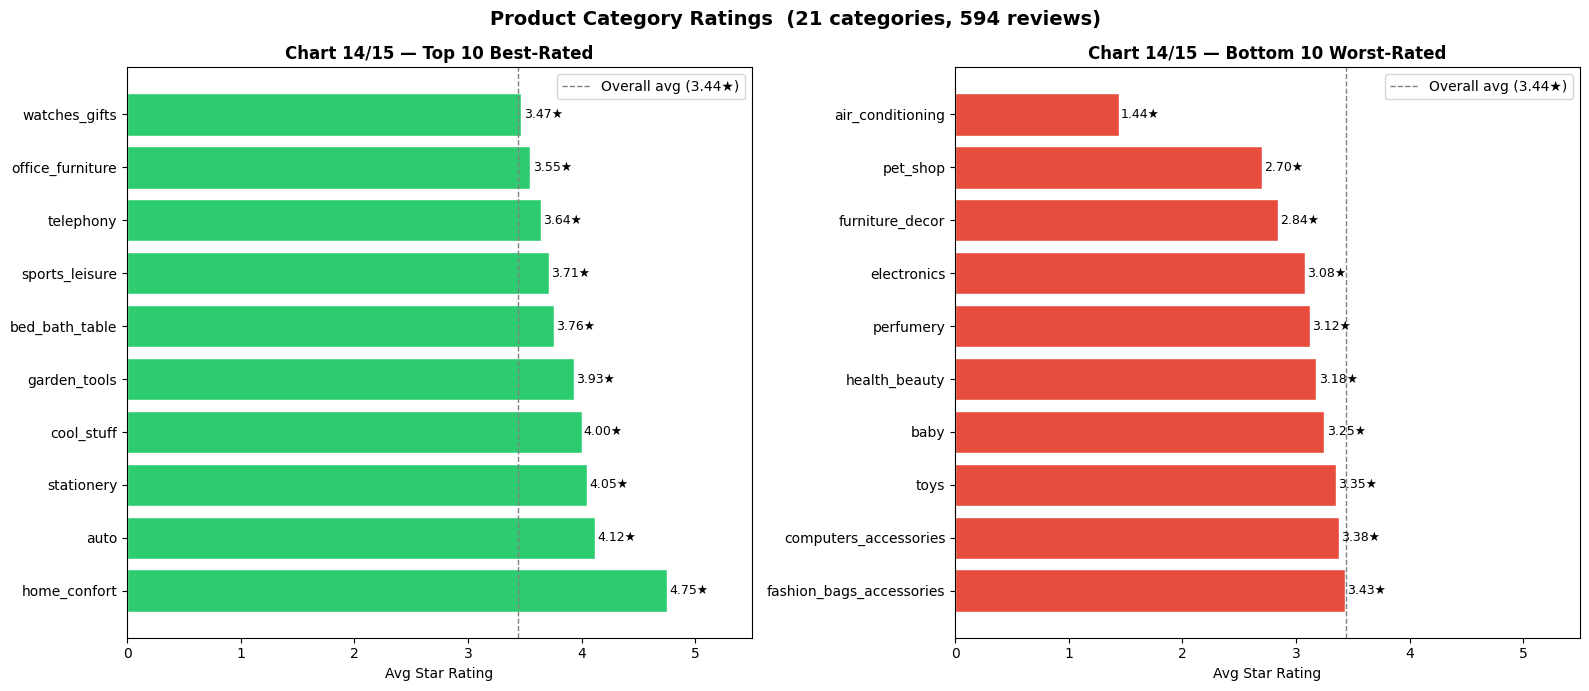

Charts 14-15 saved.


In [4]:
n_show   = min(10, len(stats))
top_n    = stats.head(n_show)
bottom_n = stats.tail(n_show)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_n,    f"Top {n_show} Best-Rated",    "#2ecc71"),
    (axes[1], bottom_n, f"Bottom {n_show} Worst-Rated", "#e74c3c"),
]:
    cats  = [c[:30] for c in data["category"].to_list()]
    stars = data["avg_stars"].to_list()
    bars  = ax.barh(cats, stars, color=color, edgecolor="white")
    for bar, v in zip(bars, stars):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{v:.2f}★", va="center", fontsize=9)
    ax.set_xlim(0, 5.5)
    ax.axvline(stats["avg_stars"].mean(), color="gray",
               linestyle="--", linewidth=1, label=f"Overall avg ({stats['avg_stars'].mean():.2f}★)")
    ax.set_title(f"Chart 14/15 — {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Avg Star Rating")
    ax.legend()

plt.suptitle(f"Product Category Ratings  ({len(stats)} categories, {total_reviews:,} reviews)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart14_15_category_ratings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts 14-15 saved.")


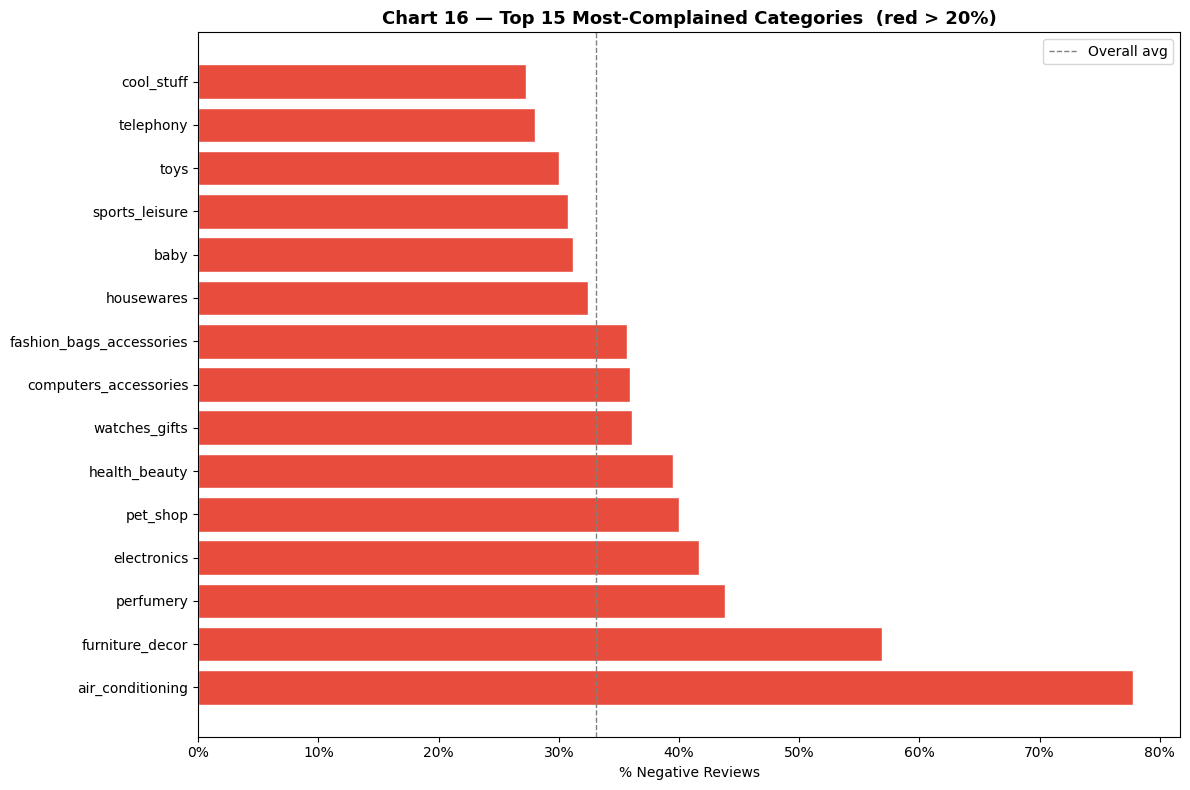

Chart 16 saved.


In [5]:
top_neg = (stats.sort("pct_negative", descending=True).head(15)
               .with_columns((pl.col("pct_negative") * 100).alias("neg_pct")))

fig, ax = plt.subplots(figsize=(12, 8))
cats    = [c[:35] for c in top_neg["category"].to_list()]
pcts    = top_neg["neg_pct"].to_list()
colors  = ["#e74c3c" if v > 20 else "#f39c12" for v in pcts]

ax.barh(cats, pcts, color=colors, edgecolor="white")
ax.axvline(stats["pct_negative"].mean() * 100, color="gray",
           linestyle="--", linewidth=1, label="Overall avg")
ax.set_title("Chart 16 — Top 15 Most-Complained Categories  (red > 20%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% Negative Reviews")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart16_most_complained_categories.png", dpi=150)
plt.show()
print("Chart 16 saved.")


In [6]:
OUTPUT_COLS = ["review_id","order_id","star_rating","sentiment","category","review_comment_message"]

# Save raw rows to DuckDB (for drill-down)
conn = duckdb.connect(DB_PATH)
conn.register("cat_df", df.select(OUTPUT_COLS))
conn.execute("CREATE OR REPLACE TABLE category_sentiment AS SELECT * FROM cat_df")
conn.close()

# Save AGGREGATED stats to CSV — this is what Power BI needs
# One row per category: avg_stars, pct_positive, pct_negative, pct_neutral, review_count
stats.write_csv("../data/category_stats.csv")

# Also save raw rows CSV (for reference)
df.select(OUTPUT_COLS).write_csv(CSV_OUT)

best     = stats.row(0, named=True)
worst    = stats.row(-1, named=True)
neg_king = stats.sort("pct_negative", descending=True).row(0, named=True)

print("=" * 55)
print("  CATEGORY SENTIMENT — SUMMARY")
print("=" * 55)
print(f"  Categories analysed  : {len(stats):,}")
print(f"  Best rated           : {best['category']}  ({best['avg_stars']:.2f}★)")
print(f"  Worst rated          : {worst['category']}  ({worst['avg_stars']:.2f}★)")
print(f"  Most complained      : {neg_king['category']}  ({neg_king['pct_negative']:.1%} negative)")
print(f"  DuckDB table         : category_sentiment  ({len(df):,} rows)")
print(f"  CSV (aggregated)     : ../data/category_stats.csv  ({len(stats)} categories)")
print(f"  CSV (raw rows)       : {CSV_OUT}")
print("=" * 55)


  CATEGORY SENTIMENT — SUMMARY
  Categories analysed  : 21
  Best rated           : home_confort  (4.75★)
  Worst rated          : air_conditioning  (1.44★)
  Most complained      : air_conditioning  (77.8% negative)
  DuckDB table         : category_sentiment  (594 rows)
  CSV (aggregated)     : ../data/category_stats.csv  (21 categories)
  CSV (raw rows)       : ../data/category_sentiment.csv
